In [1]:
import json
import numpy as np
import seaborn as sns
import pandas as pd
import mne
from mne.io import read_raw_eeglab
from mne.viz import plot_sensors
from mne.preprocessing import ICA

In [2]:
file = open('/Users/Ethan/Desktop/Machine learning downloads/ds003774/sub-001/ses-01/eeg/sub-001_ses-01_task-MusicListening_run-1_eeg.json','r')
egg_metadata= json.load(file)
egg_metadata

{'PowerLineFrequency': 50,
 'SoftwareFilters': {'FilterDescription': {'Description': 'None'}},
 'HardwareFilters': {'FilterDescription': {'Description': 'None'}},
 'SoftwareVersions': 'Netstation 5.4',
 'ManufacturersModelName': 'NetAmps 400',
 'Manufacturer': 'MagstimEG',
 'EEGPlacementScheme': 'EGI',
 'EEGGround': 'None',
 'EEGReference': 'Cz',
 'CapManufacturersModelName': '128 channel HCGSN (Hydrocel Geodesic Sensor Net)',
 'CapManufacturer': 'Magstim EGI',
 'InstitutionAddress': 'India',
 'InstitutionName': 'Indian Institute of Technology Gandhinanagar',
 'Instructions': 'The first question asked them to rate their familiarity with the song on a scale of 1 to 5, where 1 indicated extreme familiarity and 5 indicated extreme unfamiliarity to the song. The second question asked them to rate their enjoyment of the song on a scale of 1 to 5, where 1 indicated extremely enjoyable and 5 indicated extremely unenjoyable song.',
 'TaskDescription': 'The participants sat comfortably in a dar

In [3]:
channels_df = pd.read_csv('/Users/Ethan/Desktop/Machine learning downloads/ds003774/sub-001/ses-01/eeg/sub-001_ses-01_task-MusicListening_run-1_channels.tsv', sep='\t')
print(channels_df.head)

<bound method NDFrame.head of      name type   units
0      E1  EEG  microV
1      E2  EEG  microV
2      E3  EEG  microV
3      E4  EEG  microV
4      E5  EEG  microV
..    ...  ...     ...
124  E125  EEG  microV
125  E126  EEG  microV
126  E127  EEG  microV
127  E128  EEG  microV
128  E129  EEG  microV

[129 rows x 3 columns]>


/var/folders/2_/xrftwqdx3xq0bmmzkn0x7jbc0000gp/T/ipykernel_5988/1876754892.py:1: RuntimeWarning: Omitted 106 annotation(s) that were outside data range.
  raw = mne.io.read_raw_eeglab('/Users/Ethan/Desktop/Machine learning downloads/ds003774/sub-001/ses-01/eeg/sub-001_ses-01_task-MusicListening_run-1_eeg.set', preload = True)
/var/folders/2_/xrftwqdx3xq0bmmzkn0x7jbc0000gp/T/ipykernel_5988/1876754892.py:1: RuntimeWarning: Limited 2 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_eeglab('/Users/Ethan/Desktop/Machine learning downloads/ds003774/sub-001/ses-01/eeg/sub-001_ses-01_task-MusicListening_run-1_eeg.set', preload = True)
/var/folders/2_/xrftwqdx3xq0bmmzkn0x7jbc0000gp/T/ipykernel_5988/1876754892.py:1: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab('/Users/Ethan/Desktop/Machine learning downloads/ds003774/sub-001/ses-01/ee

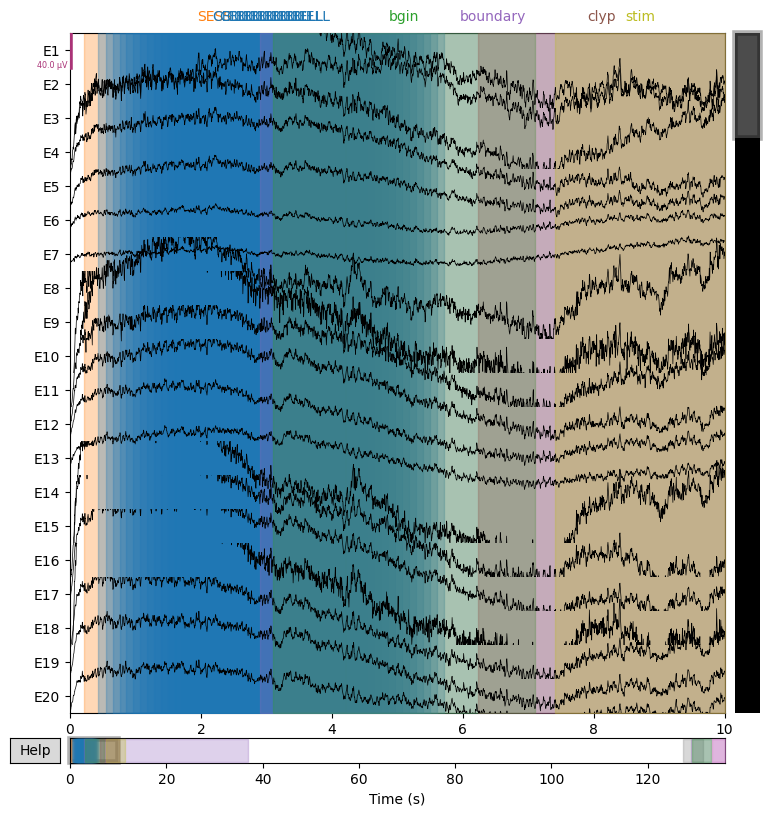

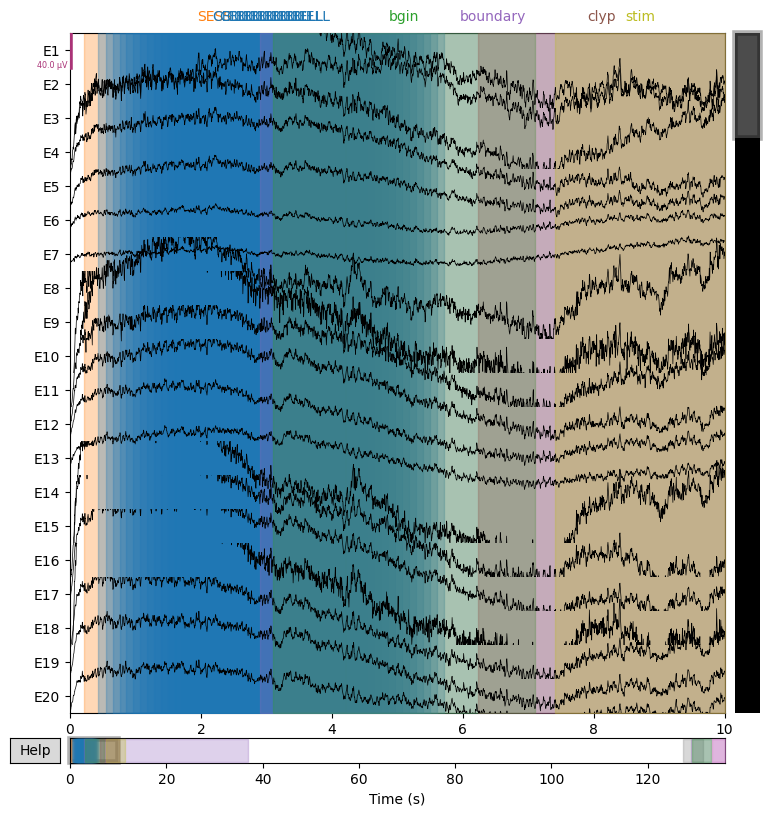

In [14]:
raw = mne.io.read_raw_eeglab('/Users/Ethan/Desktop/Machine learning downloads/ds003774/sub-001/ses-01/eeg/sub-001_ses-01_task-MusicListening_run-1_eeg.set', preload = True)
raw.info
raw.plot()

In [ ]:
raw.filter(0.5,40)

Fitting ICA to data using 129 channels (please be patient, this may take a while)


/var/folders/2_/xrftwqdx3xq0bmmzkn0x7jbc0000gp/T/ipykernel_5988/2796708434.py:2: RuntimeWarning: The data has not been high-pass filtered. For good ICA performance, it should be high-pass filtered (e.g., with a 1.0 Hz lower bound) before fitting ICA.
  ind_com_analysis.fit(raw)


Selecting by number: 15 components
Fitting ICA took 1.4s.


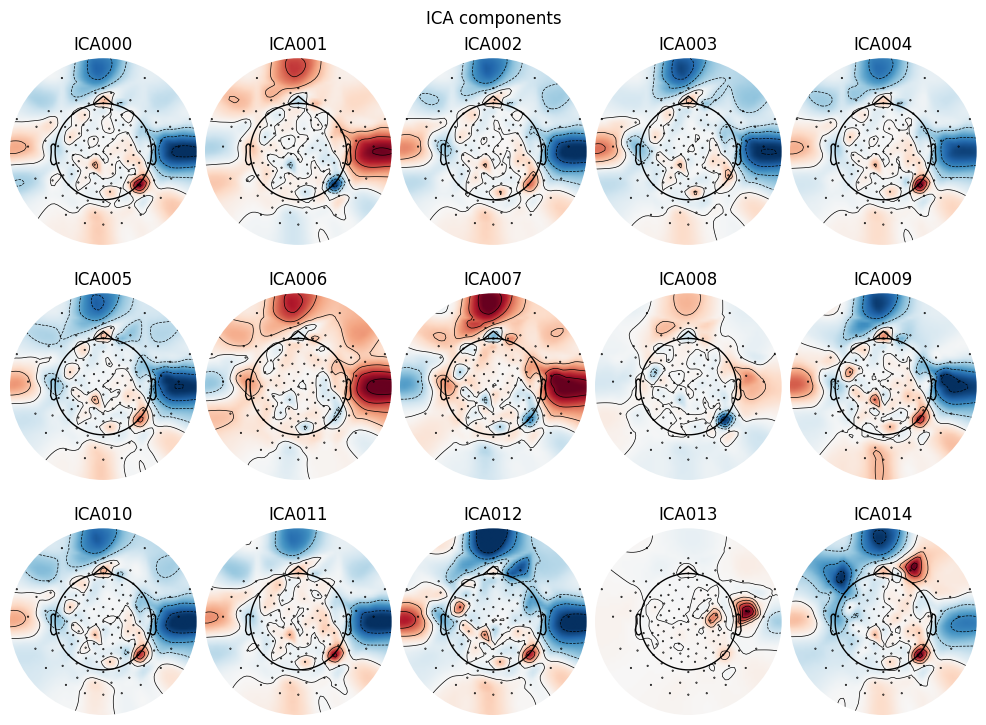

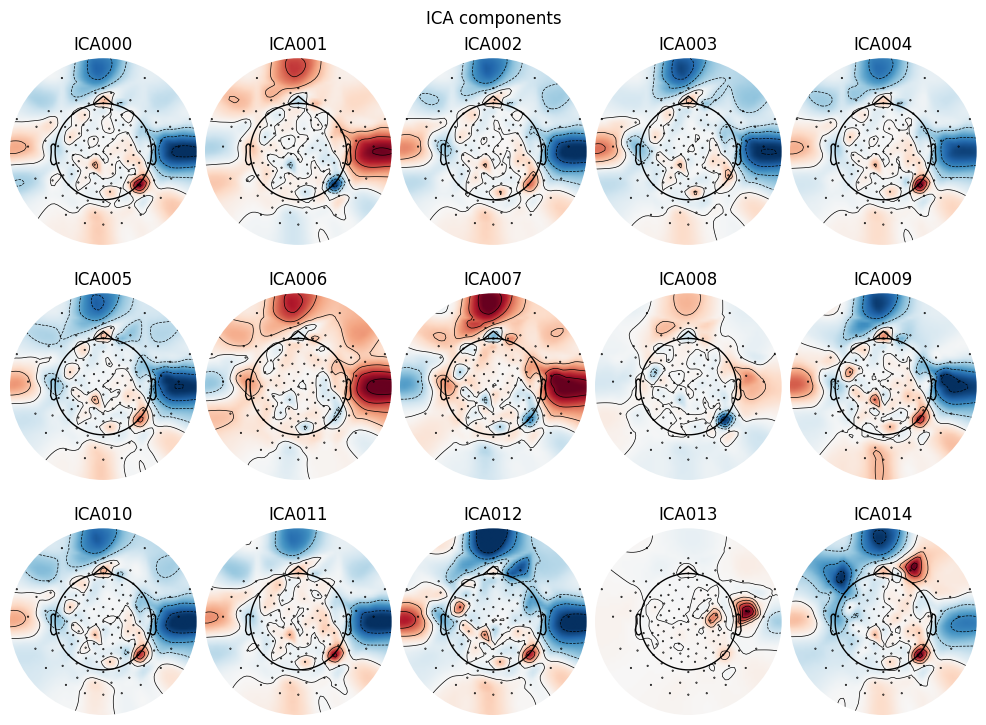

In [15]:
ind_com_analysis = ICA(n_components=15, random_state=97)
ind_com_analysis.fit(raw)
ind_com_analysis.plot_components()

In [7]:
recording_duration = raw.times[-1]
invalid_annotations = raw.annotations[(raw.annotations.onset + raw.annotations.duration) > recording_duration]
invalid_annotations

<Annotations | 2 segments: boundary (1), fxcl (1)>

In [16]:
events, event_dict = mne.events_from_annotations(raw)
# Proceed with analysis
events, event_dict = mne.events_from_annotations(raw)
epochs = mne.Epochs(raw, events, tmin=-0.2, tmax=0.8, baseline=(None, 0), preload=True, reject_by_annotation=False)

Used Annotations descriptions: [np.str_('CELL'), np.str_('SESS'), np.str_('bgin'), np.str_('boundary'), np.str_('clyp'), np.str_('fxcl'), np.str_('opyp'), np.str_('stim')]
Used Annotations descriptions: [np.str_('CELL'), np.str_('SESS'), np.str_('bgin'), np.str_('boundary'), np.str_('clyp'), np.str_('fxcl'), np.str_('opyp'), np.str_('stim')]
Not setting metadata
22 matching events found
Setting baseline interval to [-0.2, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 22 events and 251 original time points ...
0 bad epochs dropped


<Epochs | 22 events (all good), -0.2 – 0.8 s (baseline -0.2 – 0 s), ~5.6 MiB, data loaded,
 '1': 13
 '2': 1
 '3': 2
 '4': 2
 '5': 1
 '6': 1
 '7': 1
 '8': 1>


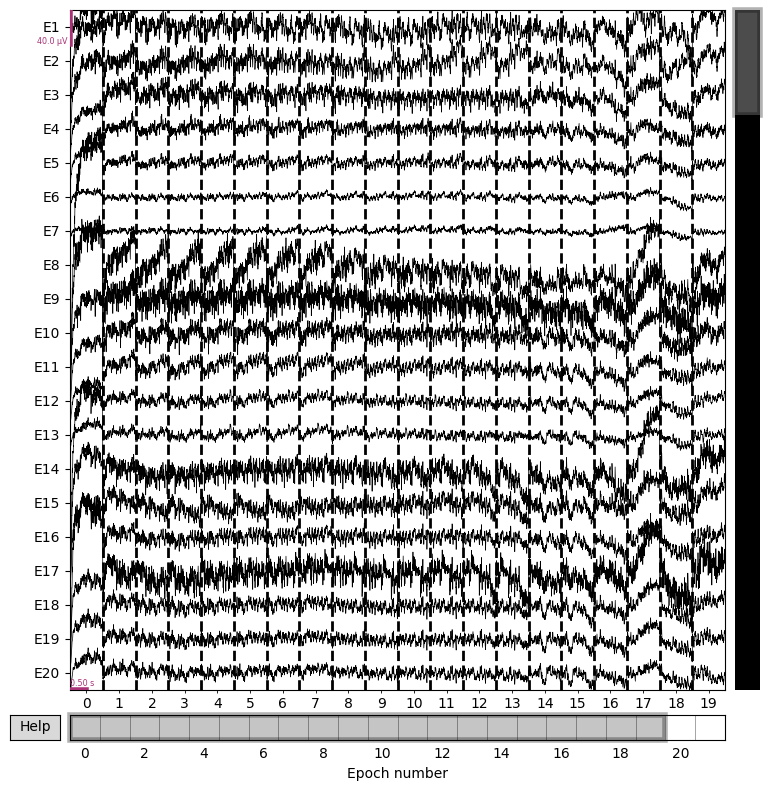

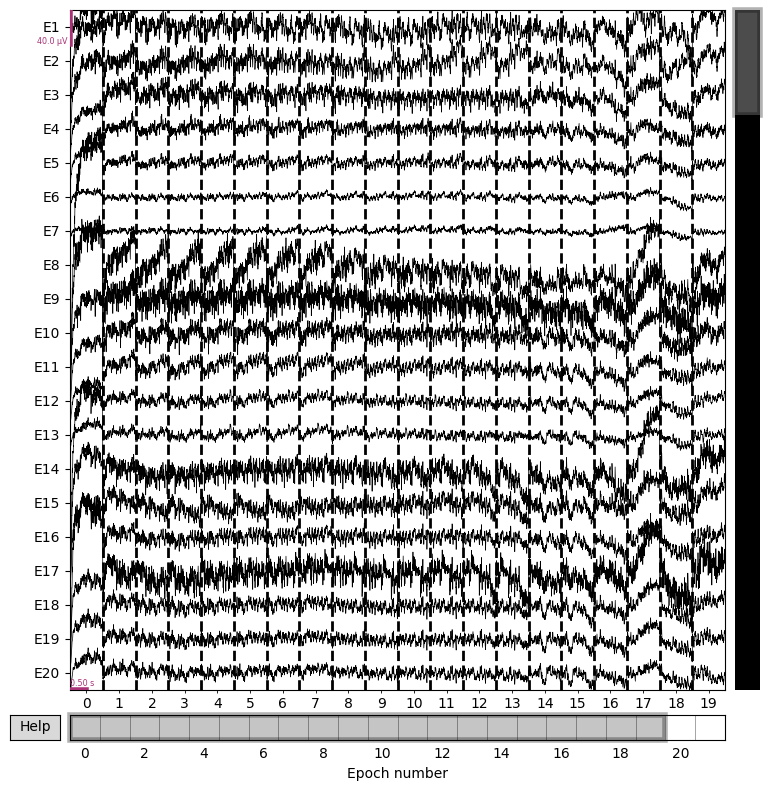

In [19]:
print(epochs)
epochs.plot()

In [ ]:
events_df = pd.read_csv('/Users/Ethan/Desktop/Machine learning downloads/ds003774/sub-001/ses-01/eeg/sub-001_ses-01_task-MusicListening_run-1_events.tsv', sep='\t')
events_df.head()
sns.countplot(x='trial_type',data= events_df)

/var/folders/2_/xrftwqdx3xq0bmmzkn0x7jbc0000gp/T/ipykernel_5988/1974085680.py:2: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  raw.set_montage(montage)


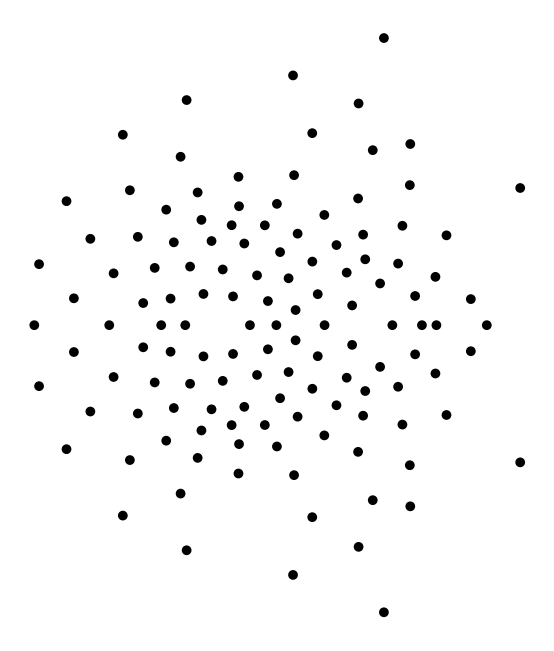

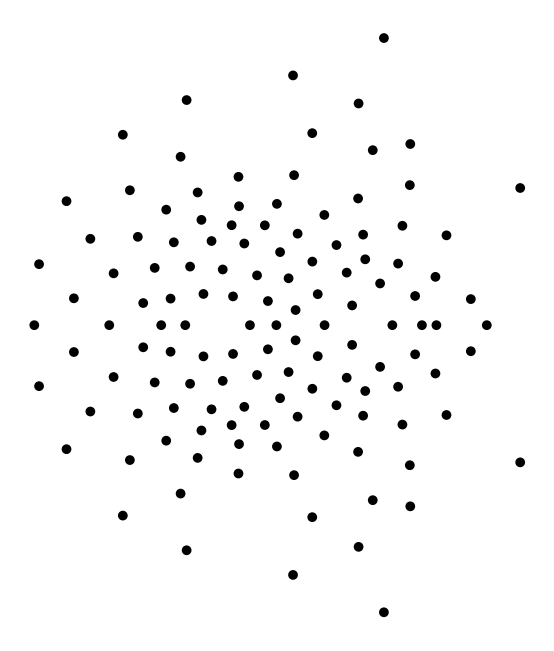

In [31]:
montage = mne.channels.read_custom_montage('/Users/Ethan/Desktop/Machine learning downloads/ds003774/sub-001/ses-01/eeg/sub-001_ses-01_task-MusicListening_run-1_electrodes.tsv')
raw.set_montage(montage)
raw.plot_sensors()

In [29]:
cordinate_file = open('/Users/Ethan/Desktop/Machine learning downloads/ds003774/sub-001/ses-01/eeg/sub-001_ses-01_task-MusicListening_run-1_coordsystem.json','r')
cordinate_system = json.load(cordinate_file)
cordinate_system

{'EEGCoordinateUnits': 'mm',
 'EEGCoordinateSystem': 'Other',
 'EEGCoordinateSystemDescription': 'EEGLAB'}